<a href="https://colab.research.google.com/github/Hansini23/Statistical-Learning-e23291/blob/main/ME2050_Assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$
$$w_{k-1} \sim \mathscr{N}(0, \Sigma_p), \quad z_k \sim \mathscr{N}(0, \Sigma_m),$$
and all random variables are mutually independent.

## Answer 1:

**Claim:** $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$ where $m_k^- = A_{k-1}m_{k-1}$ and $P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$.

**Proof:**

Since $x_k^- = A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}$ is a **linear transformation of independent Gaussian random variables**, it is itself Gaussian.

**Mean:**
$$\mathbb{E}[x_k^-] = A_{k-1}\,\mathbb{E}[x^+_{k-1}] + G_{k-1}\,\mathbb{E}[w_{k-1}] = A_{k-1}m_{k-1} + G_{k-1}\cdot 0 = A_{k-1}m_{k-1} =: m_k^-.$$

**Covariance:**
Let $\delta x^+_{k-1} = x^+_{k-1} - m_{k-1}$. Then:
$$x_k^- - m_k^- = A_{k-1}\delta x^+_{k-1} + G_{k-1}w_{k-1}.$$

Since $x^+_{k-1}$ and $w_{k-1}$ are independent:
\begin{align*}
P_k^- &= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T] \\
&= A_{k-1}\,\mathbb{E}[\delta x^+_{k-1}(\delta x^+_{k-1})^T]\,A_{k-1}^T + G_{k-1}\,\mathbb{E}[w_{k-1}w_{k-1}^T]\,G_{k-1}^T \\
&= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
\end{align*}

The cross terms vanish because $x^+_{k-1}$ and $w_{k-1}$ are independent. Therefore:
$$\boxed{x_k^- \sim \mathscr{N}(m_k^-,\; P_k^-).}$$

## Answer 2:

**Claim:** $y_k^- \sim \mathscr{N}(H_k m_k^-,\; H_k P_k^- H_k^T + \Sigma_m)$.

**Proof:**

We have $y_k^- = H_k x_k^- + z_k$, where $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$ (from Answer 1) and $z_k \sim \mathscr{N}(0, \Sigma_m)$, independent of $x_k^-$.

This is again a linear transformation of independent Gaussians, hence Gaussian.

**Mean:**
$$\mathbb{E}[y_k^-] = H_k\,\mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^- + 0 = H_k m_k^-.$$

**Covariance:**
$$\mathrm{Cov}(y_k^-) = H_k\,\mathrm{Cov}(x_k^-)\,H_k^T + \mathrm{Cov}(z_k) = H_k P_k^- H_k^T + \Sigma_m.$$

Therefore:
$$\boxed{y_k^- \sim \mathscr{N}\bigl(H_k m_k^-,\; H_k P_k^- H_k^T + \Sigma_m\bigr).}$$

## Answer 3:

**Claim:**
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\!\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

**Proof:**

The joint vector $[x_k^{-T}, y_k^{-T}]^T$ is a linear function of the Gaussian vector $[x_k^{-T}, z_k^T]^T$:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} I \\ H_k \end{bmatrix} x_k^- + \begin{bmatrix} 0 \\ I \end{bmatrix} z_k,$$
which is jointly Gaussian. The marginal means are already established. It remains to compute the joint covariance.

Let $\delta x = x_k^- - m_k^-$ and $\delta y = y_k^- - H_k m_k^-$. Then $\delta y = H_k \delta x + z_k$.

- $\mathrm{Cov}(x_k^-, x_k^-) = P_k^-$ (from Answer 1).
- $\mathrm{Cov}(y_k^-, y_k^-) = H_k P_k^- H_k^T + \Sigma_m$ (from Answer 2).
- **Cross-covariance:**
$$\mathrm{Cov}(x_k^-, y_k^-) = \mathbb{E}[\delta x\,\delta y^T] = \mathbb{E}[\delta x (H_k \delta x + z_k)^T] = \mathbb{E}[\delta x\,(\delta x)^T H_k^T] + \mathbb{E}[\delta x\,z_k^T] = P_k^- H_k^T,$$
where the last term vanishes by independence of $x_k^-$ and $z_k$.

Therefore the joint covariance matrix is:
$$\boxed{\Sigma_{\text{joint}} = \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}.}$$

## Answer 4:
$x_k^+ = (x_k^- \mid y_k^- = y_k^{\mathrm{obs}})$

**Claim:** $x_k^+ \sim \mathscr{N}(m_k, P_k)$ with the Kalman update equations.

**Proof:**

We use the standard **conditional distribution formula for jointly Gaussian vectors**. For a joint Gaussian
$$\begin{bmatrix} u \\ v \end{bmatrix} \sim \mathscr{N}\!\left(\begin{bmatrix}\mu_u \\ \mu_v\end{bmatrix}, \begin{bmatrix}\Sigma_{uu} & \Sigma_{uv} \\ \Sigma_{vu} & \Sigma_{vv}\end{bmatrix}\right),$$
the conditional distribution is:
$$(u \mid v = v_0) \sim \mathscr{N}\bigl(\mu_u + \Sigma_{uv}\Sigma_{vv}^{-1}(v_0 - \mu_v),\; \Sigma_{uu} - \Sigma_{uv}\Sigma_{vv}^{-1}\Sigma_{vu}\bigr).$$

Identifying $u = x_k^-$, $v = y_k^-$, $v_0 = y_k^{\mathrm{obs}}$, and using the joint distribution from Answer 3:

$$\mu_u = m_k^-, \quad \mu_v = H_k m_k^-, \quad \Sigma_{uu} = P_k^-, \quad \Sigma_{uv} = P_k^- H_k^T, \quad \Sigma_{vv} = H_k P_k^- H_k^T + \Sigma_m.$$

Define the **Kalman gain**:
$$K_k \triangleq \Sigma_{uv}\Sigma_{vv}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}.$$

**Updated mean:**
$$m_k = m_k^- + K_k(y_k^{\mathrm{obs}} - H_k m_k^-).$$

**Updated covariance:**
$$P_k = P_k^- - K_k(H_k P_k^- H_k^T + \Sigma_m)K_k^T - \ldots$$

More directly:
$$P_k = \Sigma_{uu} - \Sigma_{uv}\Sigma_{vv}^{-1}\Sigma_{vu} = P_k^- - P_k^- H_k^T(H_k P_k^- H_k^T + \Sigma_m)^{-1} H_k P_k^-.$$

Factoring:
$$P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k)P_k^-.$$

Therefore:
$$\boxed{x_k^+ \sim \mathscr{N}(m_k, P_k), \quad m_k = m_k^- + K_k(y_k^{\mathrm{obs}} - H_k m_k^-), \quad P_k = (I-K_k H_k)P_k^-.}$$

## Answer 5

From Answer 4, the conditional distribution $(x_k^- \mid y_k^- = y_k^{\mathrm{obs}})$ is exactly $x_k^+$, which we showed is $\mathscr{N}(m_k, P_k)$. Therefore:

$$\boxed{\mathbb{E}[x_k^- \mid y_k^- = y_k^{\mathrm{obs}}] = m_k = m_k^- + K_k(y_k^{\mathrm{obs}} - H_k m_k^-).}$$

$$\boxed{\mathrm{Var}(x_k^- \mid y_k^- = y_k^{\mathrm{obs}}) = P_k = (I - K_k H_k)P_k^-.}$$

These are exactly the Kalman filter update equations — conditioning on the observation $y_k^{\mathrm{obs}}$ reduces the covariance from $P_k^-$ to $P_k \preceq P_k^-$ (in the positive-semidefinite sense), since $(I - K_k H_k)$ has eigenvalues $\leq 1$.

---
# Q. 1-D Example

Consider the scalar linear-Gaussian model with $A_{k-1}=a$, $G_{k-1}=1$, $H_k=h$, $\Sigma_p=q$, $\Sigma_m=r$.

## Answer 1:

Setting $A_{k-1}=a$, $G_{k-1}=1$, $\Sigma_p=q$ in the general formulae from Q.Analytical Derivation Answer 1:

$$m_k^- = a\,m_{k-1} + 1\cdot 0 = a\,m_{k-1}.$$

$$P_k^- = a^2 P_{k-1}\cdot a^{0} \;\Rightarrow\; P_k^- = a^2 P_{k-1} + 1\cdot q\cdot 1 = a^2 P_{k-1} + q.$$

$$\boxed{m_k^- = a\,m_{k-1}, \qquad P_k^- = a^2 P_{k-1} + q.}$$

## Answer 2:

In the scalar case the innovation variance is $S_k = h^2 P_k^- + r$ and the Kalman gain is:
$$K_k = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}.$$

Substituting into the general update:
$$m_k = m_k^- + K_k(y_k^{\mathrm{obs}} - h\,m_k^-) = m_k^- + \frac{P_k^- h}{S_k}\,(y_k^{\mathrm{obs}} - h\,m_k^-).$$

$$P_k = (1 - K_k h)P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr)P_k^-.$$

$$\boxed{m_k = m_k^- + \frac{P_k^- h}{S_k}(y_k^{\mathrm{obs}} - h\,m_k^-), \qquad P_k = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr)P_k^-.}$$

## Answer 3: Predictive Measurement Distribution $p(y_k^- | Y_{k-1})$

From Q.Analytical Derivation Answer 2 (scalar case with $H_k = h$, $\Sigma_m = r$):

$$y_k^- \mid Y_{k-1} \sim \mathscr{N}(h\,m_k^-,\; h^2 P_k^- + r).$$

The mean is $h\,m_k^-$ and variance is $S_k = h^2 P_k^- + r$:

$$\boxed{p(y_k^- \mid Y_{k-1}) = \mathscr{N}(h\,m_k^-,\; h^2 P_k^- + r).}$$

## Answer 4:

After updating on $y_k^{\mathrm{obs}}$, we have $x_k^+ \sim \mathscr{N}(m_k, P_k)$. The posterior-predictive measurement is:
$$y_k^- \mid Y_k = h\,x_k^+ + z_k,$$
where $x_k^+ \sim \mathscr{N}(m_k, P_k)$ and $z_k \sim \mathscr{N}(0, r)$ are independent (by the same argument as Answer 2 applied to the posterior).

$$\boxed{p(y_k^- \mid Y_k) = \mathscr{N}(h\,m_k,\; h^2 P_k + r).}$$

This can be interpreted as the distribution of a hypothetical next measurement given all data seen so far.

## Answer 5:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm
from IPython.display import HTML

# ── Model parameters ──────────────────────────────────────────────────────────
a   = 0.95   # state transition (slight damping)
q   = 1.0    # process noise variance
h   = 1.0    # measurement matrix
r   = 2.0    # measurement noise variance
T   = 15     # number of time steps

# ── True state & observations ──────────────────────────────────────────────────
np.random.seed(42)
x_true = np.zeros(T + 1)
y_obs  = np.zeros(T)
x_true[0] = 3.0
for k in range(T):
    x_true[k + 1] = a * x_true[k] + np.random.randn() * np.sqrt(q)
    y_obs[k]       = h * x_true[k + 1] + np.random.randn() * np.sqrt(r)

# ── Kalman filter ──────────────────────────────────────────────────────────────
m0, P0 = 0.0, 5.0          # prior
m_prior, P_prior = [m0], [P0]
m_post,  P_post  = [],   []

m, P = m0, P0
for k in range(T):
    # Predict
    m_p = a * m
    P_p = a**2 * P + q
    S   = h**2 * P_p + r
    K   = P_p * h / S
    # Update
    m   = m_p + K * (y_obs[k] - h * m_p)
    P   = (1 - K * h) * P_p
    m_prior.append(m_p); P_prior.append(P_p)
    m_post.append(m);    P_post.append(P)

# ── Animation ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax_state, ax_meas = axes

x_range = np.linspace(-10, 14, 400)

# --- State-space panel --------------------------------------------------------
prior_line, = ax_state.plot([], [], 'b--', lw=2, label='Prior $p(x_k^-|Y_{k-1})$')
post_line,  = ax_state.plot([], [], 'r-',  lw=2, label='Posterior $p(x_k^+|Y_k)$')
obs_vline   = ax_state.axvline(np.nan, color='g', lw=1.5, ls=':', label='$y_k^{obs}$')
true_vline  = ax_state.axvline(np.nan, color='k', lw=1.5, ls='--', label='$x_k^{true}$')
ax_state.set_xlim(x_range[0], x_range[-1])
ax_state.set_ylim(0, 1.0)
ax_state.set_xlabel('State $x$', fontsize=12)
ax_state.set_ylabel('Density', fontsize=12)
ax_state.set_title('State distributions', fontsize=13)
ax_state.legend(fontsize=9)
time_text_s = ax_state.text(0.02, 0.96, '', transform=ax_state.transAxes,
                             fontsize=11, va='top')

# --- Measurement-space panel --------------------------------------------------
pred_meas_line,  = ax_meas.plot([], [], 'b--', lw=2,
                                 label='Predictive $p(y_k^-|Y_{k-1})$')
post_meas_line,  = ax_meas.plot([], [], 'r-',  lw=2,
                                 label='Post-pred $p(y_k^-|Y_k)$')
obs_vline_m      = ax_meas.axvline(np.nan, color='g', lw=1.5, ls=':', label='$y_k^{obs}$')
ax_meas.set_xlim(x_range[0], x_range[-1])
ax_meas.set_ylim(0, 0.6)
ax_meas.set_xlabel('Measurement $y$', fontsize=12)
ax_meas.set_ylabel('Density', fontsize=12)
ax_meas.set_title('Measurement distributions', fontsize=13)
ax_meas.legend(fontsize=9)
time_text_m = ax_meas.text(0.02, 0.96, '', transform=ax_meas.transAxes,
                            fontsize=11, va='top')

plt.tight_layout()

def init():
    for line in [prior_line, post_line, pred_meas_line, post_meas_line]:
        line.set_data([], [])
    obs_vline.set_xdata([np.nan])
    true_vline.set_xdata([np.nan])
    obs_vline_m.set_xdata([np.nan])
    return prior_line, post_line, pred_meas_line, post_meas_line, obs_vline, true_vline, obs_vline_m

def update(frame):
    k = frame  # step index 0..T-1
    # --- State panel ---
    mp, pp = m_prior[k+1], P_prior[k+1]
    mpo, ppo = m_post[k], P_post[k]
    prior_line.set_data(x_range, norm.pdf(x_range, mp,  np.sqrt(pp)))
    post_line.set_data( x_range, norm.pdf(x_range, mpo, np.sqrt(ppo)))
    obs_vline.set_xdata([y_obs[k]])           # observation
    true_vline.set_xdata([x_true[k+1]])       # true state
    time_text_s.set_text(f'k = {k+1}')
    ymax_s = max(norm.pdf(0, 0, np.sqrt(pp)), norm.pdf(0, 0, np.sqrt(ppo))) * 1.4
    ax_state.set_ylim(0, ymax_s)

    # --- Measurement panel ---
    # predictive:     N(h*m_p, h^2*P_p + r)
    mu_pm, var_pm = h * mp,  h**2 * pp  + r
    mu_am, var_am = h * mpo, h**2 * ppo + r
    pred_meas_line.set_data(x_range, norm.pdf(x_range, mu_pm, np.sqrt(var_pm)))
    post_meas_line.set_data(x_range, norm.pdf(x_range, mu_am, np.sqrt(var_am)))
    obs_vline_m.set_xdata([y_obs[k]])
    time_text_m.set_text(f'k = {k+1}')
    ymax_m = max(norm.pdf(0, 0, np.sqrt(var_pm)), norm.pdf(0, 0, np.sqrt(var_am))) * 1.4
    ax_meas.set_ylim(0, ymax_m)

    return prior_line, post_line, pred_meas_line, post_meas_line, obs_vline, true_vline, obs_vline_m

ani = animation.FuncAnimation(fig, update, frames=T, init_func=init,
                               interval=900, blit=False)
plt.close()
HTML(ani.to_jshtml())

---
# Q. 2D-Position Estimation
## Part A:

### Derivation of $A$

The **constant-velocity** kinematic equations with time step $\Delta t$ are:
\begin{align*}
p_x(k) &= p_x(k-1) + \Delta t\,v_x(k-1), \\
p_y(k) &= p_y(k-1) + \Delta t\,v_y(k-1), \\
v_x(k) &= v_x(k-1), \\
v_y(k) &= v_y(k-1).
\end{align*}

In matrix form $x_k^{\text{nom}} = A\,x_{k-1}^+$:

$$\begin{bmatrix}p_x(k)\\p_y(k)\\v_x(k)\\v_y(k)\end{bmatrix}
= \underbrace{\begin{bmatrix}1 & 0 & \Delta t & 0\\0 & 1 & 0 & \Delta t\\0 & 0 & 1 & 0\\0 & 0 & 0 & 1\end{bmatrix}}_{A}
\begin{bmatrix}p_x(k-1)\\p_y(k-1)\\v_x(k-1)\\v_y(k-1)\end{bmatrix}.$$

### Derivation of $H$

The measurement is only the position:
$$y_k = \begin{bmatrix}p_x^{\text{meas}}(k)\\p_y^{\text{meas}}(k)\end{bmatrix}
= \begin{bmatrix}1 & 0 & 0 & 0\\0 & 1 & 0 & 0\end{bmatrix}
\begin{bmatrix}p_x\\p_y\\v_x\\v_y\end{bmatrix} + z_k
\quad\Rightarrow\quad
H = \begin{bmatrix}1 & 0 & 0 & 0\\0 & 1 & 0 & 0\end{bmatrix}.$$

### Derivation of $G$

The process noise $w_{k-1} = [w_x, w_y]^T \sim \mathscr{N}(0, \Sigma_p)$ represents **acceleration** disturbances. Under a constant-acceleration approximation over $\Delta t$, a random acceleration $w_x$ changes position by $\frac{1}{2}\Delta t^2 w_x$ and velocity by $\Delta t\, w_x$. Hence:

$$x_k^- = A\,x_{k-1}^+ + G\,w_{k-1}, \quad G = \begin{bmatrix}\tfrac{1}{2}\Delta t^2 & 0\\0 & \tfrac{1}{2}\Delta t^2\\\Delta t & 0\\0 & \Delta t\end{bmatrix}.$$

$$\boxed{A = \begin{bmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{bmatrix},\quad
H = \begin{bmatrix}1&0&0&0\\0&1&0&0\end{bmatrix},\quad
G = \begin{bmatrix}\tfrac{1}{2}\Delta t^2&0\\0&\tfrac{1}{2}\Delta t^2\\\Delta t&0\\0&\Delta t\end{bmatrix}.}$$

## Part B:

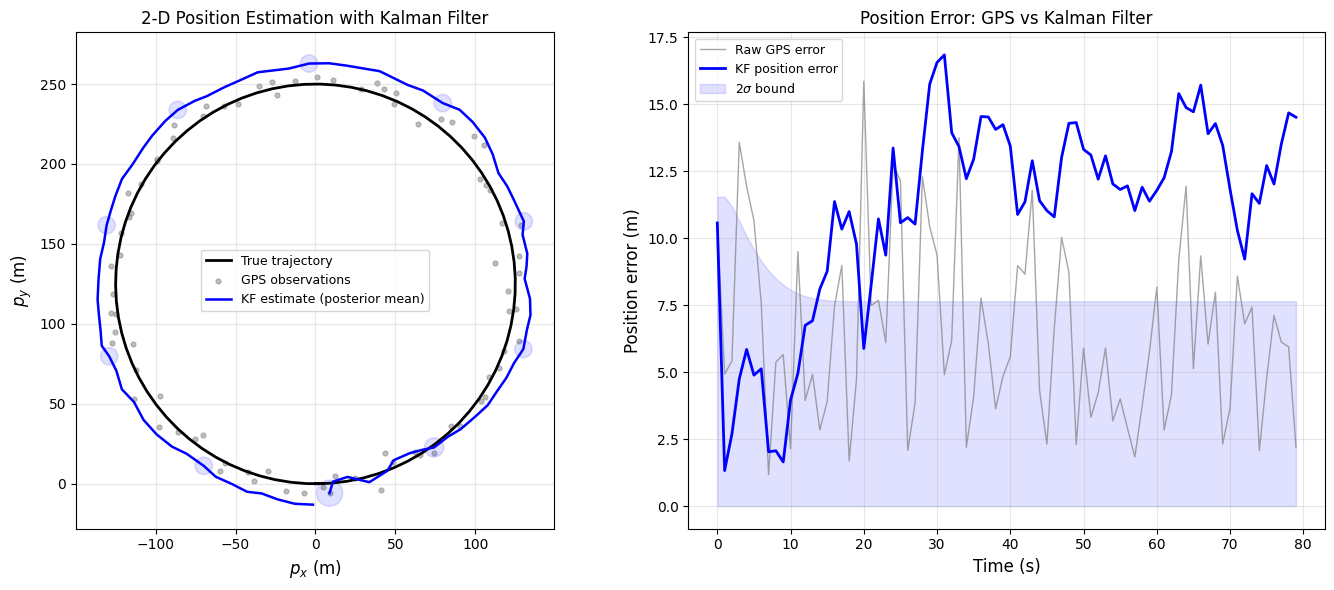

Mean GPS error : 6.41 m
Mean KF  error : 11.02  m


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ══════════════════════════════════════════════════════════════════════════════
#  Kalman Filter class for a 2-D constant-velocity model
# ══════════════════════════════════════════════════════════════════════════════
class KalmanFilter2D:
    """
    2-D constant-velocity Kalman filter.

    State  : x = [px, py, vx, vy]^T
    Obs    : y = [px_meas, py_meas]^T

    Parameters
    ----------
    dt       : time step (s)
    sigma_p  : scalar process-noise std  (acceleration noise)
    sigma_m  : scalar measurement-noise std (GPS position noise, m)
    """

    def __init__(self, dt=1.0, sigma_p=0.5, sigma_m=3.0):
        self.dt = dt

        # State transition matrix
        self.A = np.array([[1, 0, dt, 0],
                           [0, 1, 0, dt],
                           [0, 0, 1,  0],
                           [0, 0, 0,  1]], dtype=float)

        # Measurement matrix (observe position only)
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]], dtype=float)

        # Process-noise input matrix
        self.G = np.array([[0.5 * dt**2, 0],
                           [0, 0.5 * dt**2],
                           [dt,          0],
                           [0,          dt]], dtype=float)

        # Process-noise covariance:  Sigma_p = sigma_p^2 * I_2
        self.Sigma_p = sigma_p**2 * np.eye(2)

        # Measurement-noise covariance:  Sigma_m = sigma_m^2 * I_2
        self.Sigma_m = sigma_m**2 * np.eye(2)

    # ------------------------------------------------------------------
    def predict(self, m, P):
        """Predict step: returns (m_prior, P_prior)."""
        m_pred = self.A @ m
        P_pred = self.A @ P @ self.A.T + self.G @ self.Sigma_p @ self.G.T
        return m_pred, P_pred

    # ------------------------------------------------------------------
    def update(self, m_pred, P_pred, y_obs):
        """Update step: returns (m_post, P_post, K, innovation)."""
        S = self.H @ P_pred @ self.H.T + self.Sigma_m          # innovation cov
        K = P_pred @ self.H.T @ np.linalg.inv(S)               # Kalman gain
        v = y_obs - self.H @ m_pred                             # innovation
        m_post = m_pred + K @ v
        P_post = (np.eye(4) - K @ self.H) @ P_pred
        return m_post, P_post, K, v

    # ------------------------------------------------------------------
    def run(self, observations, m0, P0):
        """
        Filter a sequence of observations.

        Parameters
        ----------
        observations : (T, 2) array of GPS measurements [px, py]
        m0 : (4,) initial state mean
        P0 : (4,4) initial state covariance

        Returns
        -------
        dict with arrays of predicted and posterior means/covariances.
        """
        T = len(observations)
        m_preds, P_preds = [], []
        m_posts, P_posts = [], []

        m, P = m0.copy(), P0.copy()
        for k in range(T):
            m_p, P_p = self.predict(m, P)
            m, P = self.update(m_p, P_p, observations[k])[:2]
            m_preds.append(m_p); P_preds.append(P_p)
            m_posts.append(m);   P_posts.append(P)

        return dict(
            m_preds=np.array(m_preds), P_preds=np.array(P_preds),
            m_posts=np.array(m_posts), P_posts=np.array(P_posts)
        )


# ══════════════════════════════════════════════════════════════════════════════
#  Simulate a curved trajectory and noisy GPS
# ══════════════════════════════════════════════════════════════════════════════
np.random.seed(0)

dt       = 1.0    # 1-second time steps
T        = 80     # 80 time steps
sigma_p  = 0.3    # process noise (acceleration std, m/s²)
sigma_m  = 5.0    # GPS noise std (m)

# True trajectory: circular arc + linear drift
t_arr   = np.arange(T) * dt
omega   = 0.08                         # turn rate (rad/s)
speed   = 10.0                         # m/s
px_true = speed / omega * np.sin(omega * t_arr)
py_true = speed / omega * (1 - np.cos(omega * t_arr))

# Noisy GPS observations
obs = np.column_stack([
    px_true + np.random.randn(T) * sigma_m,
    py_true + np.random.randn(T) * sigma_m
])

# ── Run the filter ────────────────────────────────────────────────────────────
kf   = KalmanFilter2D(dt=dt, sigma_p=sigma_p, sigma_m=sigma_m)
m0   = np.array([obs[0, 0], obs[0, 1], 0.0, 0.0])  # initialise from 1st GPS fix
P0   = np.diag([sigma_m**2, sigma_m**2, 5.0**2, 5.0**2])
res  = kf.run(obs, m0, P0)

# ══════════════════════════════════════════════════════════════════════════════
#  Helper: 2-sigma ellipse for a 2×2 covariance sub-matrix
# ══════════════════════════════════════════════════════════════════════════════
def cov_ellipse(ax, mean, cov2x2, n_std=2, color='r', alpha=0.15, lw=1.2):
    evals, evecs = np.linalg.eigh(cov2x2)
    angle = np.degrees(np.arctan2(*evecs[:, 1][::-1]))
    w, h = 2 * n_std * np.sqrt(np.abs(evals))
    ell  = Ellipse(mean, w, h, angle=angle,
                   edgecolor=color, facecolor=color, alpha=alpha, linewidth=lw)
    ax.add_patch(ell)

# ══════════════════════════════════════════════════════════════════════════════
#  Plot
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: trajectory overview ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(px_true, py_true, 'k-',  lw=2,   label='True trajectory')
ax.scatter(obs[:, 0], obs[:, 1], s=12, c='grey', alpha=0.5, label='GPS observations')
ax.plot(res['m_posts'][:, 0], res['m_posts'][:, 1], 'b-', lw=1.8,
        label='KF estimate (posterior mean)')

# Draw a few uncertainty ellipses
for k in range(0, T, 8):
    cov_ellipse(ax,
                res['m_posts'][k, :2],
                res['P_posts'][k][:2, :2],
                color='blue', alpha=0.12)

ax.set_aspect('equal')
ax.set_xlabel('$p_x$ (m)', fontsize=12)
ax.set_ylabel('$p_y$ (m)', fontsize=12)
ax.set_title('2-D Position Estimation with Kalman Filter', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Right: position error over time ──────────────────────────────────────────
ax2 = axes[1]
pos_est = res['m_posts'][:, :2]
pos_true = np.column_stack([px_true, py_true])
err_kf  = np.linalg.norm(pos_est  - pos_true, axis=1)
err_raw = np.linalg.norm(obs - pos_true, axis=1)

ax2.plot(t_arr, err_raw, 'grey', lw=1, alpha=0.7, label='Raw GPS error')
ax2.plot(t_arr, err_kf,  'b-',  lw=2,             label='KF position error')
# 2-sigma bound from P
std_pos = np.sqrt(res['P_posts'][:, 0, 0] + res['P_posts'][:, 1, 1])
ax2.fill_between(t_arr, 0, 2 * std_pos, color='blue', alpha=0.12, label='$2\\sigma$ bound')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Position error (m)', fontsize=12)
ax2.set_title('Position Error: GPS vs Kalman Filter', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_2d_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mean GPS error : {err_raw.mean():.2f} m")
print(f"Mean KF  error : {err_kf.mean():.2f}  m")